# Trend-Following Directional POC — Hyperliquid Perps (4h MA-crossover)

A slim, reproducible POC for a **directional** perp strategy on **real Hyperliquid
data**. After an exhaustive search (high-frequency microstructure, cross-sectional,
RL/ML, plain time-series momentum), the one approach that survives **leakage-free,
funding-aware, walk-forward + regime-split** scrutiny is classic **trend-following**:
a moving-average crossover at the 4-hour horizon, equal-weight long/short across the
liquid core perps.

**Why this and not RL/microstructure:**
- High-frequency directional (1–5m, order-flow/microstructure) had **no edge after
  taker costs** (IC≈0, signs flip OOS) — microstructure alpha is maker/market-making.
- Plain `sign(momentum)` TSMOM looked great only due to a backtest bias + ignoring
  funding; corrected, it dies (all edge in the short leg, one regime).
- **MA-crossover** has hysteresis → low turnover (~0.02 flips/bar) → survives funding
  to ~50% APR, is positive across a broad parameter plateau and 6/7 symbols and 5/6
  walk-forward folds, and works in **both** up and down sub-periods.
- RL/ML (QR-DQN, LightGBM) overfit and **underperformed the rule** — not used.

**Honest caveats (read before trusting):** ~8 months of data that is mostly one
regime; the up-market evidence is a short window; a sustained-bull / chop out-of-sample
is still unproven. This is a *paper-probe-grade* edge, not validated for capital — run
it forward (shadow→paper) to accumulate genuine OOS before sizing.

In [1]:
import json
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# config
CORE = ["BTC", "ETH", "SOL", "LINK", "ARB", "OP", "HYPER"]
TF = "4h"
BARS_YR = 2190.0                 # 4h bars per year (annualization)
MA_FAST, MA_SLOW = 24, 96        # 4-day vs 16-day MA (robust plateau center)
FEE_BPS = 4.5                    # Hyperliquid taker, per side, on |Δposition|
FUNDING_APR = 0.20               # conservative short-book funding drag (stressed)
SPLIT_TS = "2026-02-26"          # train/test boundary (test = held-out tail)
UP_END = "2026-02-01"           # regime split (before = up-market, after = down/alt-bear)
DATA_CSV = "data/hyperliquid_4h_core.csv"  # exported from platform-postgres (Hyperliquid)

## 1. Load real Hyperliquid 4h OHLC (core perps)
Bundled CSV exported from `platform-postgres` (`ohlcs`, timeframe=4h). To refresh from
the live venue, see the optional Hyperliquid-API cell at the end.

In [2]:
df = pd.read_csv(DATA_CSV, parse_dates=["ts"]).sort_values(["symbol", "ts"]).reset_index(drop=True)
df = df[df.symbol.isin(CORE)].copy()
df["ret"] = df.groupby("symbol")["close"].pct_change()
df["fwd"] = df.groupby("symbol")["ret"].shift(-1)     # next-bar return (the only forward info; label for PnL)
print(f"symbols={sorted(df.symbol.unique())} rows={len(df)} {df.ts.min()} -> {df.ts.max()}")
# contiguity check (gap-free is required so MA windows are true clock time)
for s in CORE:
    t = df[df.symbol == s]["ts"]
    gaps = (t.diff().dt.total_seconds() / (4 * 3600)).fillna(1)
    assert (gaps <= 1).all(), f"{s} has gaps — MA windows would span gaps"
print("contiguity OK (no gaps; MA windows are true 4h clock time)")

symbols=['ARB', 'BTC', 'ETH', 'HYPER', 'LINK', 'OP', 'SOL'] rows=10451 2025-09-30 00:00:00+00:00 -> 2026-06-05 16:00:00+00:00
contiguity OK (no gaps; MA windows are true 4h clock time)


## 2. Strategy + leakage-free backtest engine
Signal at bar *t*: `sign(MA_fast[t] − MA_slow[t])` using closes up to and including *t*.
Realized PnL uses the **next-bar** return; cost charged on turnover `|Δpos|`; funding
drag on held exposure. Signals are computed on **full per-symbol history** (never on a
pre-sliced window — that was the bias that inflated earlier results).

In [3]:
def signal(g):
    fast = g["close"].rolling(MA_FAST).mean()
    slow = g["close"].rolling(MA_SLOW).mean()
    return np.sign((fast - slow).values)

def metrics(net):
    n = np.asarray(net, float); n = n[np.isfinite(n)]
    if len(n) == 0 or n.std() == 0:
        return dict(ret_pct=0.0, sharpe=0.0, mdd_pct=0.0, hit=0.0, n=int(len(n)))
    eq = np.cumprod(1 + n); peak = np.maximum.accumulate(eq)
    return dict(ret_pct=round(100 * (eq[-1] - 1), 2),
                sharpe=round(float(n.mean() / n.std() * math.sqrt(BARS_YR)), 3),
                mdd_pct=round(100 * float(np.max((peak - eq) / peak)), 2),
                hit=round(float((n > 0).mean()), 3), n=int(len(n)))

def backtest(pos_func, fee_bps=FEE_BPS, funding_apr=FUNDING_APR, universe=CORE,
             ts_min=None, ts_max=None, return_curve=False):
    cost = fee_bps / 1e4
    fund = funding_apr * 4.0 / 8760.0      # per 4h bar
    per_bar = {}
    for s in universe:
        g = df[df.symbol == s].sort_values("ts")          # FULL history -> no head-of-window bias
        if len(g) < MA_SLOW + 5:
            continue
        pos = np.nan_to_num(pos_func(g))
        dp = np.abs(np.diff(np.concatenate([[0.0], pos])))
        net = pos * np.nan_to_num(g["fwd"].values) - dp * cost - np.abs(pos) * fund
        ts = g["ts"].values
        keep = np.ones(len(g), bool)
        if ts_min is not None: keep &= ts >= np.datetime64(pd.Timestamp(ts_min))
        if ts_max is not None: keep &= ts < np.datetime64(pd.Timestamp(ts_max))
        for t, x, k in zip(ts, net, keep):
            if k: per_bar.setdefault(t, []).append(x)
    items = sorted(per_bar.items())
    series = [np.mean(v) for _, v in items]
    m = metrics(series)
    if return_curve:
        return m, pd.Series(np.cumprod(1 + np.array(series)), index=[t for t, _ in items])
    return m

## 3. Headline results: full-period, held-out test, walk-forward, regimes, per-symbol

In [4]:
full = backtest(signal)
test = backtest(signal, ts_min=SPLIT_TS)
test_nofund = backtest(signal, ts_min=SPLIT_TS, funding_apr=0.0)
up = backtest(signal, ts_max=UP_END)
down = backtest(signal, ts_min=UP_END)
print(f"MA-crossover ({MA_FAST}/{MA_SLOW}) @ {TF}, equal-weight long/short core-7, "
      f"fee={FEE_BPS}bps, funding={int(FUNDING_APR*100)}%APR")
print(f"  FULL  : {full}")
print(f"  TEST  (>= {SPLIT_TS}, funded): {test}")
print(f"  TEST  (no funding)          : {test_nofund}")
print(f"  UP-market   (< {UP_END}): {up}")
print(f"  DOWN-market (>= {UP_END}): {down}")

# walk-forward (6 contiguous OOS folds)
times = np.sort(df["ts"].unique())
b = [times[int(len(times) * i / 6)] for i in range(6)] + [None]
print("\n  Walk-forward (6 folds):")
wf = []
for i in range(6):
    m = backtest(signal, ts_min=b[i], ts_max=b[i + 1])
    wf.append(m["sharpe"])
    lo = pd.Timestamp(b[i]).date(); hi = (pd.Timestamp(b[i + 1]).date() if b[i + 1] is not None else "end")
    print(f"    fold {i} [{lo}..{hi}]: SR={m['sharpe']:>6} ret={m['ret_pct']:>7}%")
print(f"    folds positive: {sum(s>0 for s in wf)}/6 | mean SR {round(float(np.mean(wf)),3)}")

# per-symbol
print("\n  Per-symbol (test, funded):")
for s in CORE:
    m = backtest(signal, universe=[s], ts_min=SPLIT_TS)
    print(f"    {s:5s} SR={m['sharpe']:>6} ret={m['ret_pct']:>7}%")

# funding stress
print("\n  Funding stress (test):")
for fa in (0.0, 0.10, 0.20, 0.30, 0.50):
    m = backtest(signal, ts_min=SPLIT_TS, funding_apr=fa)
    print(f"    {int(fa*100):>3}% APR -> SR={m['sharpe']:>6} ret={m['ret_pct']:>7}%")

MA-crossover (24/96) @ 4h, equal-weight long/short core-7, fee=4.5bps, funding=20%APR
  FULL  : {'ret_pct': np.float64(33.42), 'sharpe': 1.033, 'mdd_pct': 28.53, 'hit': 0.466, 'n': 1493}
  TEST  (>= 2026-02-26, funded): {'ret_pct': np.float64(18.52), 'sharpe': 1.587, 'mdd_pct': 18.17, 'hit': 0.504, 'n': 599}
  TEST  (no funding)          : {'ret_pct': np.float64(25.18), 'sharpe': 2.025, 'mdd_pct': 16.81, 'hit': 0.511, 'n': 599}
  UP-market   (< 2026-02-01): {'ret_pct': np.float64(-3.58), 'sharpe': 0.122, 'mdd_pct': 28.53, 'hit': 0.423, 'n': 744}
  DOWN-market (>= 2026-02-01): {'ret_pct': np.float64(38.37), 'sharpe': 2.099, 'mdd_pct': 18.9, 'hit': 0.509, 'n': 749}

  Walk-forward (6 folds):
    fold 0 [2025-09-30..2025-11-10]: SR=-1.491 ret= -11.85%
    fold 1 [2025-11-10..2025-12-21]: SR=-0.198 ret=  -3.64%
    fold 2 [2025-12-21..2026-02-01]: SR= 2.472 ret=  14.77%
    fold 3 [2026-02-01..2026-03-14]: SR= 2.548 ret=  16.18%
    fold 4 [2026-03-14..2026-04-25]: SR= 1.317 ret=   5.81%
 

     30% APR -> SR= 1.369 ret=  15.32%
     50% APR -> SR= 0.931 ret=   9.18%


/tmp/ipykernel_3292302/996920554.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  if ts_min is not None: keep &= ts >= np.datetime64(pd.Timestamp(ts_min))
/tmp/ipykernel_3292302/996920554.py:31: UserWarning: no explicit representation of timezones available for np.datetime64
  if ts_max is not None: keep &= ts < np.datetime64(pd.Timestamp(ts_max))


## 4. Baselines + equity curves

TEST  strategy: {'ret_pct': np.float64(18.52), 'sharpe': 1.587, 'mdd_pct': 18.17, 'hit': 0.504, 'n': 599}
TEST  buy&hold: {'ret_pct': np.float64(-19.28), 'sharpe': -1.12, 'mdd_pct': 36.03, 'hit': 0.511, 'n': 599}
TEST  always-flat: ret 0.0%, SR 0.0


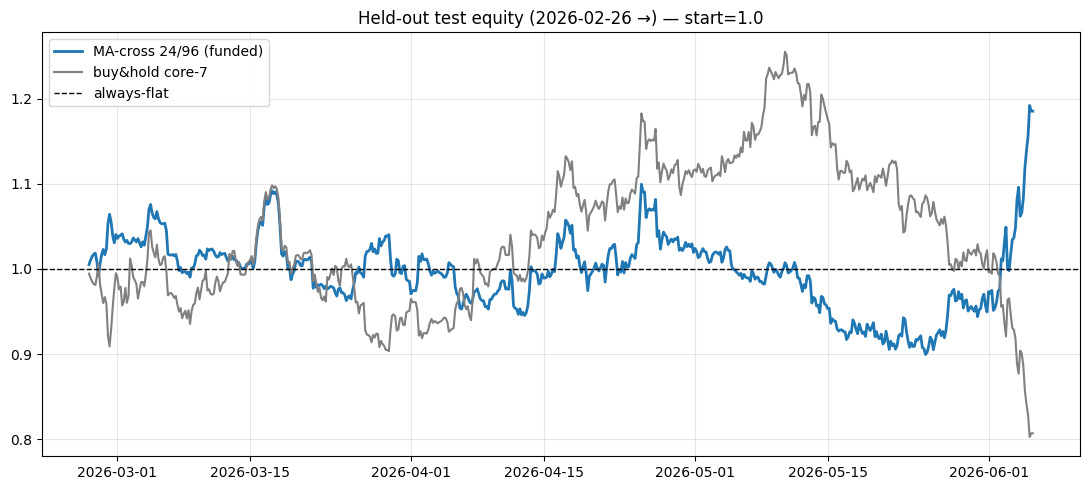

In [5]:
def flat_curve(ts_min):
    return backtest(lambda g: np.zeros(len(g)), ts_min=ts_min, return_curve=True)
def buyhold(g): return np.ones(len(g))   # equal-weight long all core perps

m_strat, eq_strat = backtest(signal, ts_min=SPLIT_TS, return_curve=True)
m_bh, eq_bh = backtest(buyhold, ts_min=SPLIT_TS, funding_apr=0.0, return_curve=True)
print(f"TEST  strategy: {m_strat}\nTEST  buy&hold: {m_bh}\nTEST  always-flat: ret 0.0%, SR 0.0")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eq_strat.index, eq_strat.values, label=f"MA-cross {MA_FAST}/{MA_SLOW} (funded)", lw=2)
ax.plot(eq_bh.index, eq_bh.values, label="buy&hold core-7", color="gray")
ax.axhline(1.0, color="k", ls="--", lw=1, label="always-flat")
ax.set_title(f"Held-out test equity ({SPLIT_TS} →) — start=1.0"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs("validation_results", exist_ok=True)
plt.savefig("validation_results/mom_perp_poc_equity.png", dpi=120, bbox_inches="tight"); plt.show()

## 5. Save validation artifacts

In [6]:
results = {
    "strategy": f"MA_crossover_{MA_FAST}_{MA_SLOW}_{TF}", "universe": CORE,
    "fee_bps": FEE_BPS, "funding_apr": FUNDING_APR, "split_ts": SPLIT_TS,
    "full": full, "test_funded": test, "test_nofunding": test_nofund,
    "up_market": up, "down_market": down,
    "walk_forward_sharpe": [round(float(s), 3) for s in wf], "wf_folds_positive": int(sum(s > 0 for s in wf)),
    "baselines": {"buy_hold": m_bh, "always_flat": {"ret_pct": 0.0, "sharpe": 0.0}},
    "caveats": ["~8 months data, mostly one (down/alt-bear) regime",
                "up-market evidence is a short window; sustained-bull/chop OOS unproven",
                "paper-probe grade, not validated for capital — run forward shadow/paper first"],
}
with open("validation_results/mom_perp_poc_results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print("saved validation_results/mom_perp_poc_results.json + _equity.png")

saved validation_results/mom_perp_poc_results.json + _equity.png


## 6. (Optional) Refresh data from the live Hyperliquid public API
Reproduces the dataset from the actual venue (public, no keys). Uncomment to refresh.

In [7]:
# import urllib.request
# def hl_candles(coin, interval="4h", days=250):
#     import time
#     end = 1780000000000  # set to a fixed ms timestamp for reproducibility, or int(time.time()*1000)
#     start = end - days * 24 * 3600 * 1000
#     req = urllib.request.Request("https://api.hyperliquid.xyz/info",
#         data=json.dumps({"type": "candleSnapshot",
#                          "req": {"coin": coin, "interval": interval, "startTime": start, "endTime": end}}).encode(),
#         headers={"Content-Type": "application/json"})
#     c = json.loads(urllib.request.urlopen(req, timeout=30).read())
#     return pd.DataFrame([{"symbol": coin, "ts": pd.to_datetime(x["t"], unit="ms", utc=True),
#                           "open": float(x["o"]), "high": float(x["h"]), "low": float(x["l"]),
#                           "close": float(x["c"]), "volume": float(x["v"]), "count": int(x["n"])} for x in c])
# fresh = pd.concat([hl_candles(s) for s in CORE], ignore_index=True)
# fresh.to_csv(DATA_CSV, index=False)